In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [18]:
# Task 1
print(tf.__version__)


2.19.0


In [19]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


In [20]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)


In [21]:
# Task 2
test_generator = test_datagen.flow(
    x_test,
    y_test,
    batch_size=32,
    shuffle=False
)


In [22]:
train_generator = train_datagen.flow(
    x_train,
    y_train,
    batch_size=32,
    subset='training'
)

val_generator = train_datagen.flow(
    x_train,
    y_train,
    batch_size=32,
    subset='validation'
)


In [23]:
# Task 3

print(len(train_generator))


1250


In [24]:
base_model = MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

extract_feat_model = Model(inputs=base_model.input, outputs=output)


/tmp/ipython-input-3666245324.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [25]:
# Task 4
extract_feat_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 16, 16,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 16, 16,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 16, 16,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 16, 16,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 16, 16,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 16, 16,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 16, 16,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 16, 16,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 17, 17,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 8, 8, 96)  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 8, 8, 96)  │          0 │ block_1_depthwis… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 8, 8, 24)  │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
# Task 5
extract_feat_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [27]:
history_extract = extract_feat_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)


Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 68s 49ms/step - accuracy: 0.2630 - loss: 2.0348 - val_accuracy: 0.3259 - val_loss: 1.8763
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 45ms/step - accuracy: 0.3299 - loss: 1.8561 - val_accuracy: 0.3346 - val_loss: 1.8429
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 50ms/step - accuracy: 0.3443 - loss: 1.8097 - val_accuracy: 0.3395 - val_loss: 1.8242


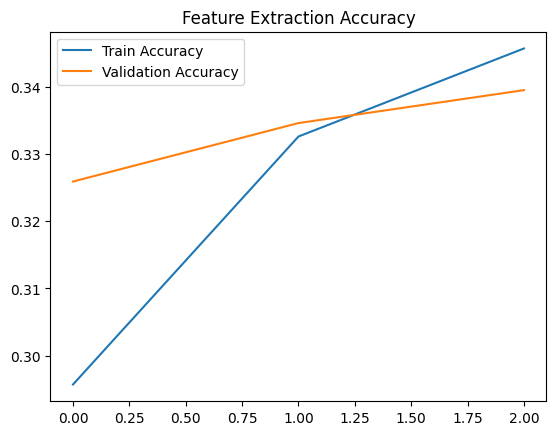

In [28]:
# Task 6
plt.plot(history_extract.history['accuracy'], label='Train Accuracy')
plt.plot(history_extract.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Feature Extraction Accuracy")
plt.show()


In [29]:
base_model.trainable = True

extract_feat_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = extract_feat_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)


Epoch 1/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 289s 205ms/step - accuracy: 0.1459 - loss: 9.2015 - val_accuracy: 0.1364 - val_loss: 3.8881
Epoch 2/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 250s 200ms/step - accuracy: 0.2183 - loss: 3.7462 - val_accuracy: 0.1890 - val_loss: 2.4167
Epoch 3/3
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 249s 199ms/step - accuracy: 0.2440 - loss: 2.5683 - val_accuracy: 0.2554 - val_loss: 2.1946


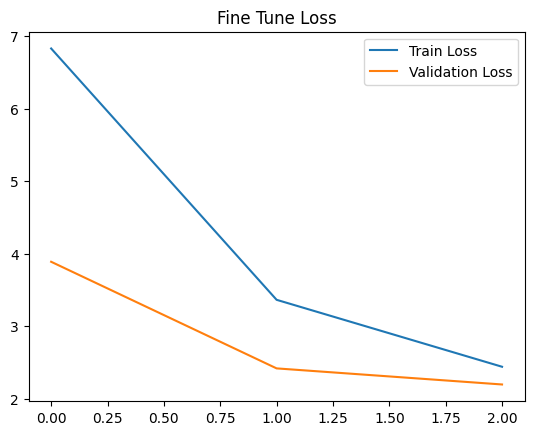

In [30]:
# Task 7
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Fine Tune Loss")
plt.show()


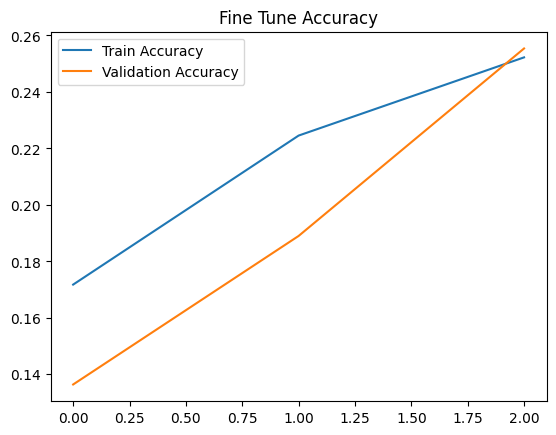

In [31]:
# Task 8
plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Fine Tune Accuracy")
plt.show()


In [32]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


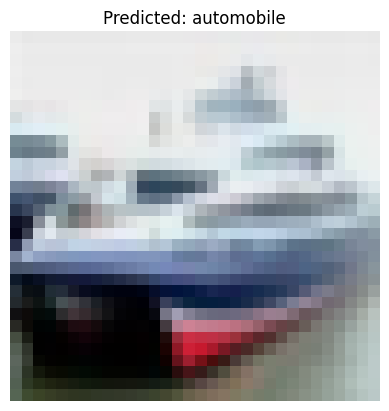

In [33]:
# Task 9
index_to_plot = 1

img = x_test[index_to_plot] / 255.0
img_input = np.expand_dims(img, axis=0)

pred = extract_feat_model.predict(img_input)
pred_label = class_names[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Predicted: {pred_label}")
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


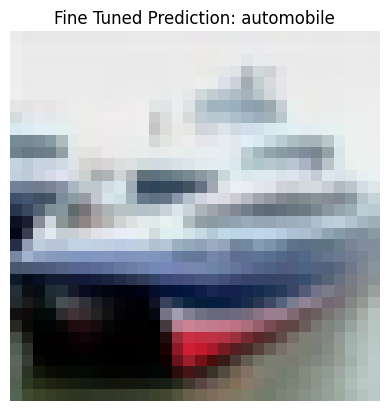

In [34]:
# Task 10
pred = extract_feat_model.predict(img_input)
pred_label = class_names[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Fine Tuned Prediction: {pred_label}")
plt.axis('off')
plt.show()